# Comparative Analysis of Emotion Models

This notebook compares the four trained emotion classifiers in this repository: VGG16, ResNet50, DenseNet121, and ViT.

It reads the saved training history plus the existing notebook outputs so the comparison is reproducible without retraining.

## What This Notebook Covers

- Best training and validation performance from the saved history file
- Training vs validation accuracy and loss curves for all models
- Test-set metrics: accuracy, precision, recall, F1-score, weighted average, and macro average
- A quick comparison of the single-image inference examples already recorded in each model notebook

In [6]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.dpi'] = 150

ROOT = Path('.')
HISTORY_PATH = ROOT / 'training_history.json'
NOTEBOOKS = {
    'VGG16': ROOT / 'vgg' / 'notebook.ipynb',
    'ResNet50': ROOT / 'resnet' / 'notebook.ipynb',
    'DenseNet121': ROOT / 'densenet' / 'notebook.ipynb',
    'ViT': ROOT / 'vit' / 'notebook.ipynb',
}
MODEL_ORDER = ['VGG16', 'ResNet50', 'DenseNet121', 'ViT']


In [7]:
with open(HISTORY_PATH, 'r', encoding='utf-8') as handle:
    history = json.load(handle)

def collect_text_outputs(notebook_path):
    with open(notebook_path, 'r', encoding='utf-8') as handle:
        notebook = json.load(handle)

    chunks = []
    for cell in notebook.get('cells', []):
        for output in cell.get('outputs', []):
            text = output.get('text')
            if isinstance(text, list):
                chunks.append(''.join(text))
            elif isinstance(text, str):
                chunks.append(text)

            data = output.get('data', {})
            text_plain = data.get('text/plain')
            if isinstance(text_plain, list):
                chunks.append(''.join(text_plain))
            elif isinstance(text_plain, str):
                chunks.append(text_plain)

    return '\n'.join(chunks)

def parse_metric_line(text, label):
    for line in text.splitlines():
        if label in line:
            value_part = line.split(':', 1)[1].strip()
            try:
                return float(value_part.split()[0])
            except (ValueError, IndexError):
                return np.nan
    return np.nan

def parse_inference_block(text):
    result = {'true_label': '', 'predicted_label': '', 'confidence': np.nan, 'result': ''}
    for line in text.splitlines():
        stripped = line.strip()
        if stripped.startswith('True label :'):
            result['true_label'] = stripped.split(':', 1)[1].strip()
        elif stripped.startswith('Predicted  :'):
            payload = stripped.split(':', 1)[1].strip()
            if '(confidence:' in payload:
                label_text, confidence_text = payload.split('(confidence:', 1)
                result['predicted_label'] = label_text.strip()
                result['confidence'] = float(confidence_text.replace('%', '').replace(')', '').strip()) / 100.0
            else:
                result['predicted_label'] = payload
        elif stripped.startswith('Result     :'):
            result['result'] = stripped.split(':', 1)[1].strip()
    return result

In [8]:
rows = []
inference_rows = []

for model_name in MODEL_ORDER:
    hist = history[model_name]
    notebook_text = collect_text_outputs(NOTEBOOKS[model_name])
    inference = parse_inference_block(notebook_text)

    val_acc = np.asarray(hist['val_acc'], dtype=float)
    val_loss = np.asarray(hist['val_loss'], dtype=float)
    best_val_acc_epoch = int(val_acc.argmax()) + 1
    best_val_loss_epoch = int(val_loss.argmin()) + 1

    rows.append({
        'model': model_name,
        'epochs': len(hist['train_acc']),
        'best_val_acc': float(val_acc.max()),
        'best_val_acc_epoch': best_val_acc_epoch,
        'best_val_loss': float(val_loss.min()),
        'best_val_loss_epoch': best_val_loss_epoch,
        'final_train_acc': float(hist['train_acc'][-1]),
        'final_val_acc': float(hist['val_acc'][-1]),
        'final_train_loss': float(hist['train_loss'][-1]),
        'final_val_loss': float(hist['val_loss'][-1]),
        'test_accuracy': parse_metric_line(notebook_text, 'Accuracy'),
        'weighted_precision': parse_metric_line(notebook_text, 'Weighted Precision'),
        'weighted_recall': parse_metric_line(notebook_text, 'Weighted Recall'),
        'weighted_f1': parse_metric_line(notebook_text, 'Weighted F1-Score'),
        'macro_precision': parse_metric_line(notebook_text, 'Macro Precision'),
        'macro_recall': parse_metric_line(notebook_text, 'Macro Recall'),
        'macro_f1': parse_metric_line(notebook_text, 'Macro F1-Score'),
        'inference_true_label': inference['true_label'],
        'inference_predicted_label': inference['predicted_label'],
        'inference_confidence': inference['confidence'],
        'inference_result': inference['result'],
    })
    inference_rows.append({
        'model': model_name,
        'true_label': inference['true_label'],
        'predicted_label': inference['predicted_label'],
        'confidence': inference['confidence'],
        'result': inference['result'],
    })

comparison_df = pd.DataFrame(rows).set_index('model').loc[MODEL_ORDER]
inference_df = pd.DataFrame(inference_rows).set_index('model').loc[MODEL_ORDER]

pd.options.display.float_format = '{:.4f}'.format
comparison_df

,epochs,best_val_acc,best_val_acc_epoch,best_val_loss,best_val_loss_epoch,final_train_acc,final_val_acc,final_train_loss,final_val_loss,test_accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1,inference_true_label,inference_predicted_label,inference_confidence,inference_result
model,,,,,,,,,,,,,,,,,,,,
VGG16,24,0.9062,14,0.3802,6,0.9942,0.8756,0.0234,0.8349,0.9325,0.9370,0.9325,0.9306,0.9370,0.9325,0.9306,Sadness,Sadness,0.5839,✅ CORRECT
ResNet50,22,0.8266,12,0.8113,6,0.9957,0.7116,0.0127,2.0598,0.8841,0.8998,0.8841,0.8777,0.8998,0.8841,0.8777,Sadness,Sadness,0.9991,✅ CORRECT
DenseNet121,30,0.8684,20,0.6339,20,0.9993,0.7972,0.0022,1.3923,0.8888,0.9060,0.8888,0.8733,0.9060,0.8888,0.8733,Sadness,Sadness,0.9279,✅ CORRECT
ViT,20,0.1709,10,2.0804,6,0.2184,0.1534,1.9604,2.1580,0.1891,0.1216,0.1891,0.1392,0.1216,0.1891,0.1392,Sadness,Anger,0.1487,❌ INCORRECT


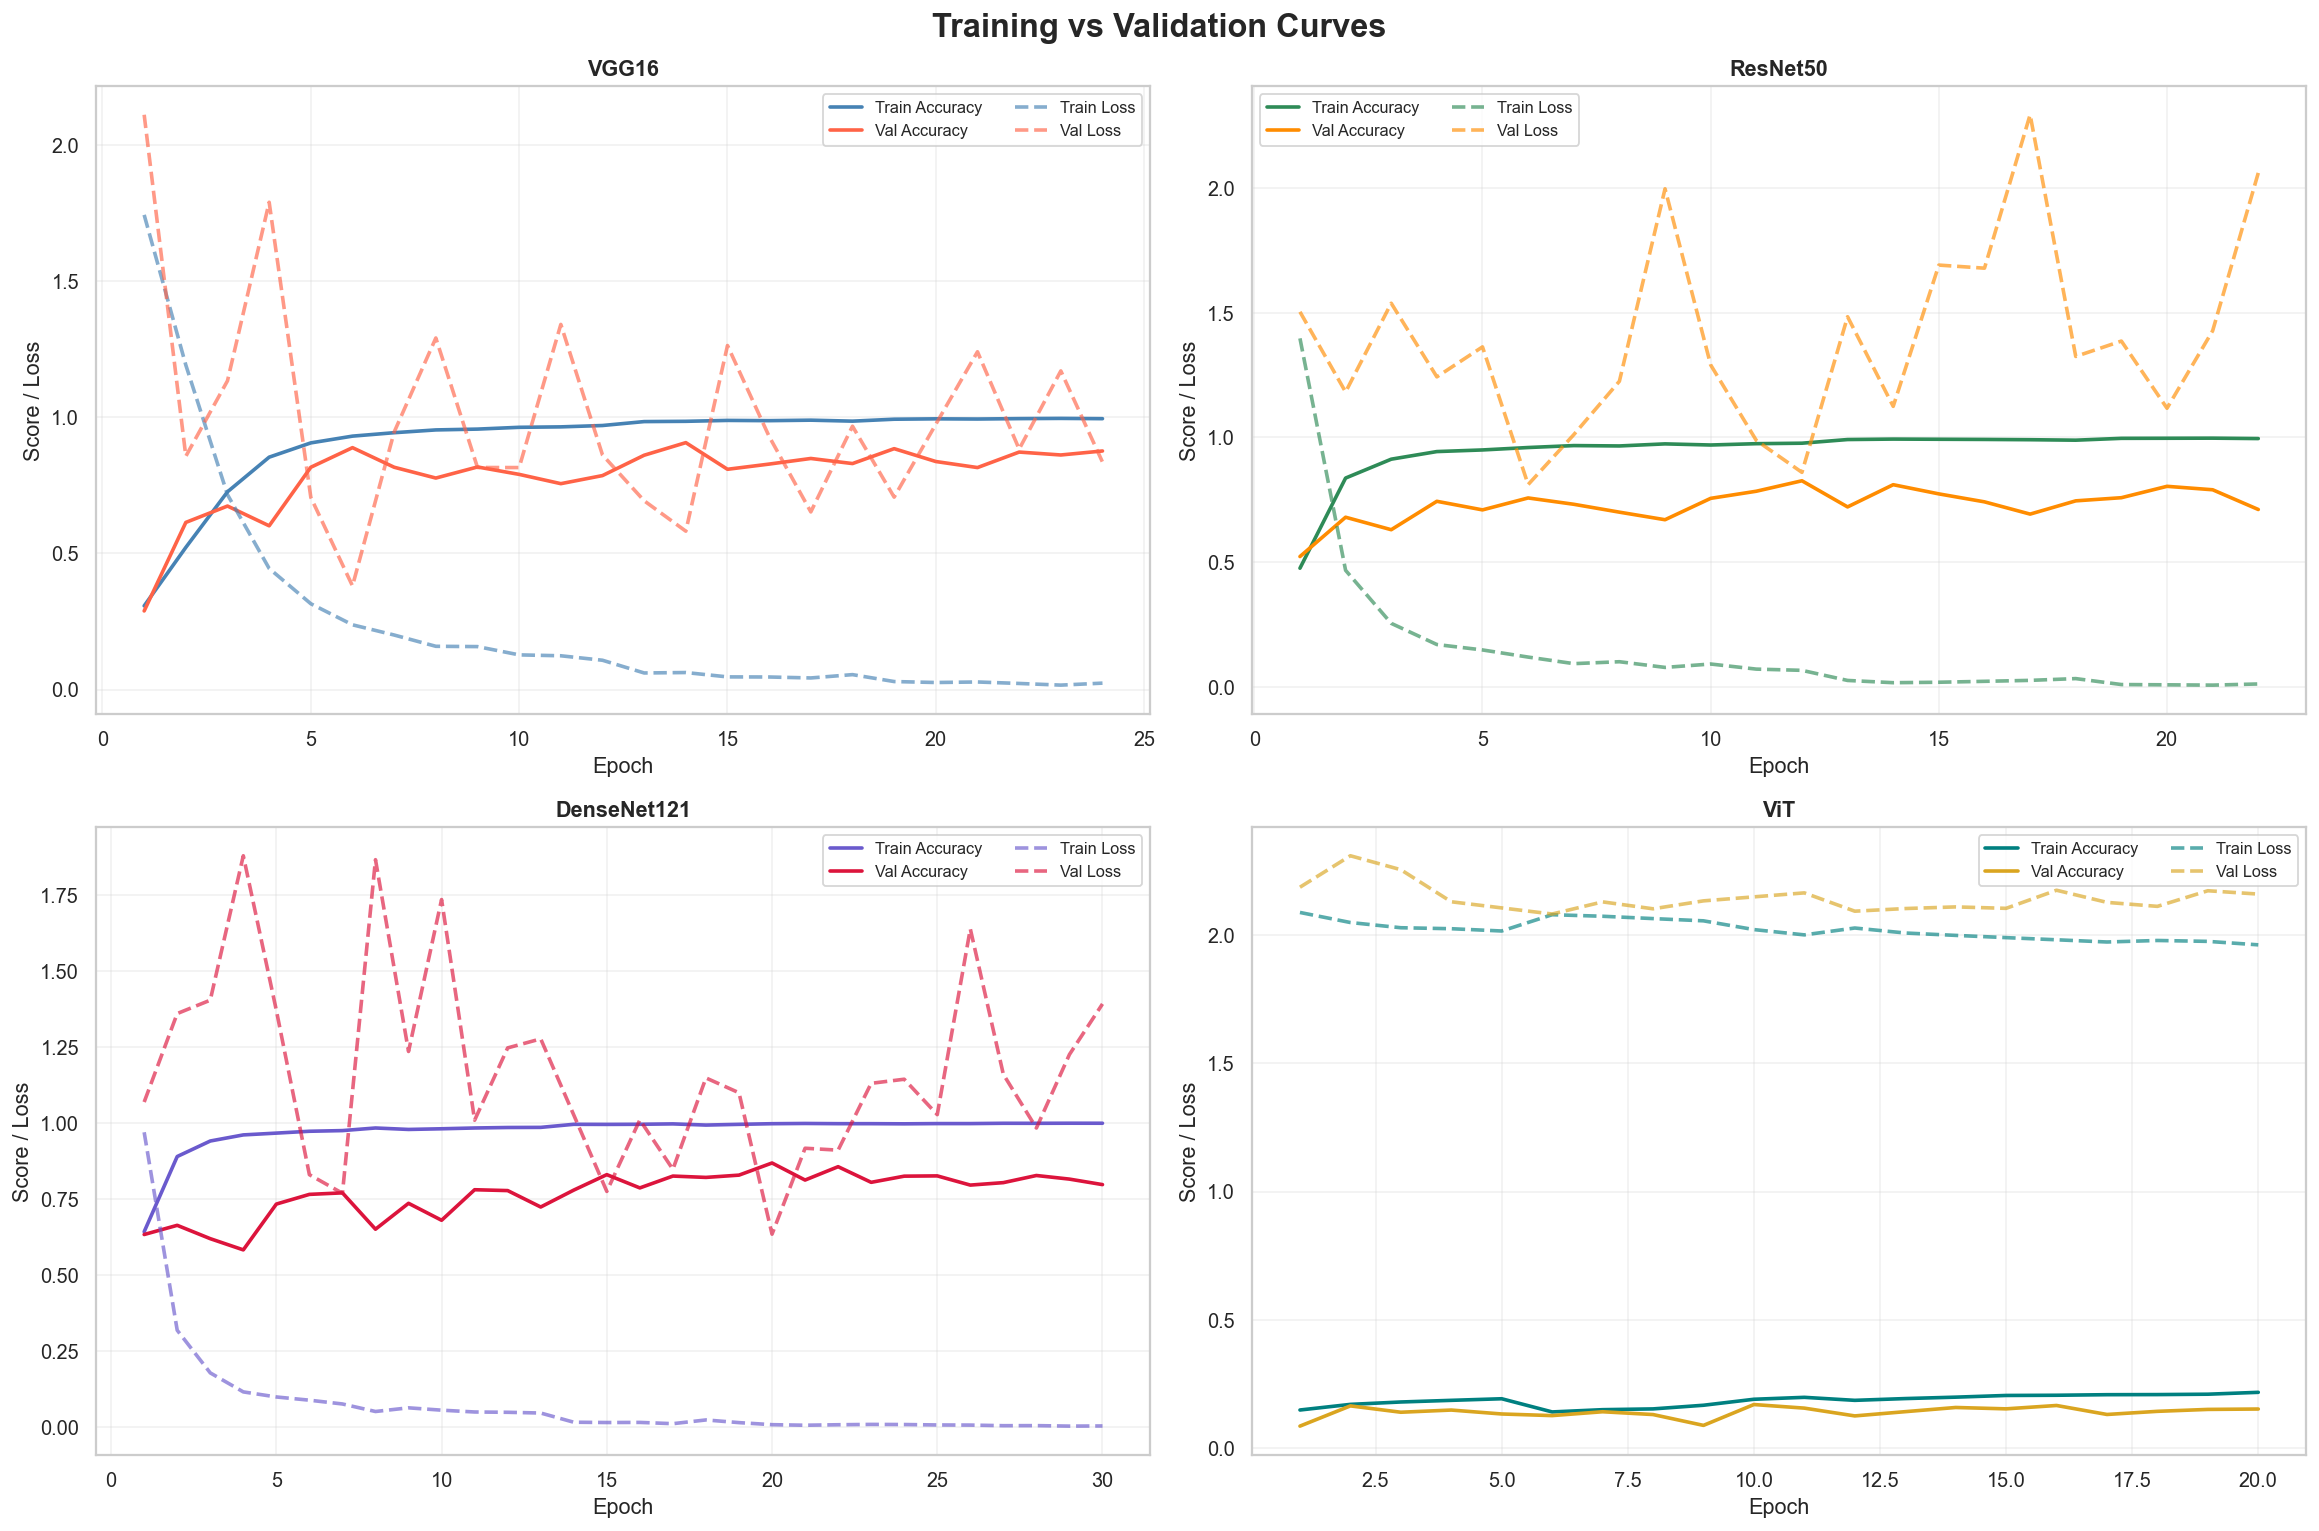

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=False)
fig.suptitle('Training vs Validation Curves', fontsize=18, fontweight='bold')

curve_styles = {
    'VGG16': {'train': 'steelblue', 'val': 'tomato'},
    'ResNet50': {'train': 'seagreen', 'val': 'darkorange'},
    'DenseNet121': {'train': 'slateblue', 'val': 'crimson'},
    'ViT': {'train': 'teal', 'val': 'goldenrod'},
}

for ax, model_name in zip(axes.flat, MODEL_ORDER):
    hist = history[model_name]
    epochs = np.arange(1, len(hist['train_acc']) + 1)
    colors = curve_styles[model_name]

    ax.plot(epochs, hist['train_acc'], color=colors['train'], linewidth=2, label='Train Accuracy')
    ax.plot(epochs, hist['val_acc'], color=colors['val'], linewidth=2, label='Val Accuracy')
    ax.plot(epochs, hist['train_loss'], color=colors['train'], linestyle='--', linewidth=2, alpha=0.65, label='Train Loss')
    ax.plot(epochs, hist['val_loss'], color=colors['val'], linestyle='--', linewidth=2, alpha=0.65, label='Val Loss')
    ax.set_title(model_name, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score / Loss')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('comparison_training_curves.png', bbox_inches='tight')
plt.show()

,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
model,,,,,,,
VGG16,0.9325,0.9370,0.9325,0.9306,0.9370,0.9325,0.9306
ResNet50,0.8841,0.8998,0.8841,0.8777,0.8998,0.8841,0.8777
DenseNet121,0.8888,0.9060,0.8888,0.8733,0.9060,0.8888,0.8733
ViT,0.1891,0.1216,0.1891,0.1392,0.1216,0.1891,0.1392


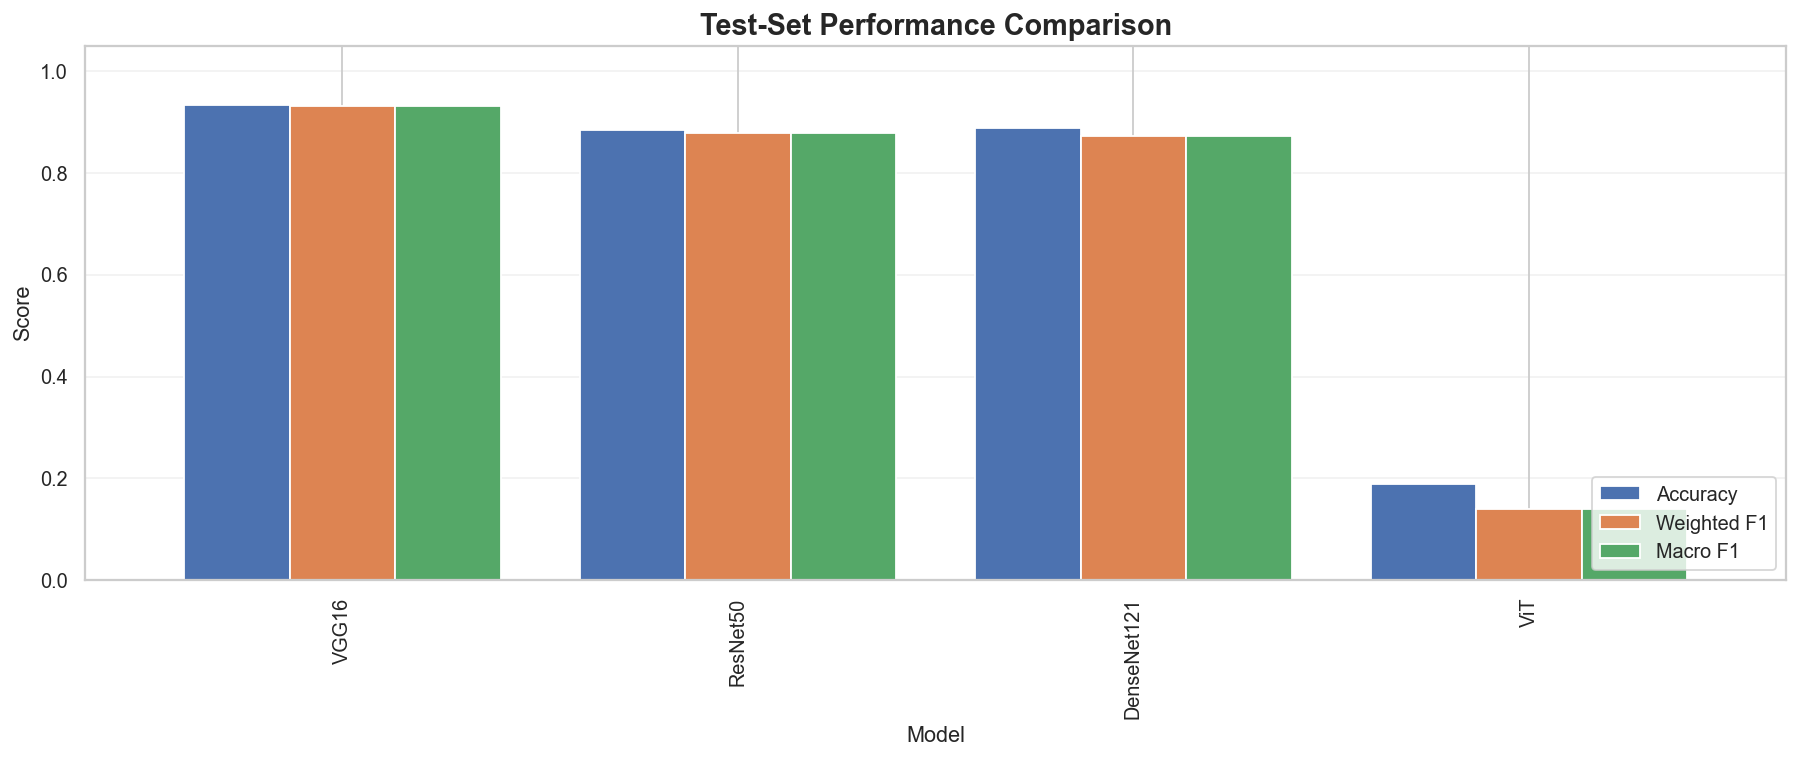

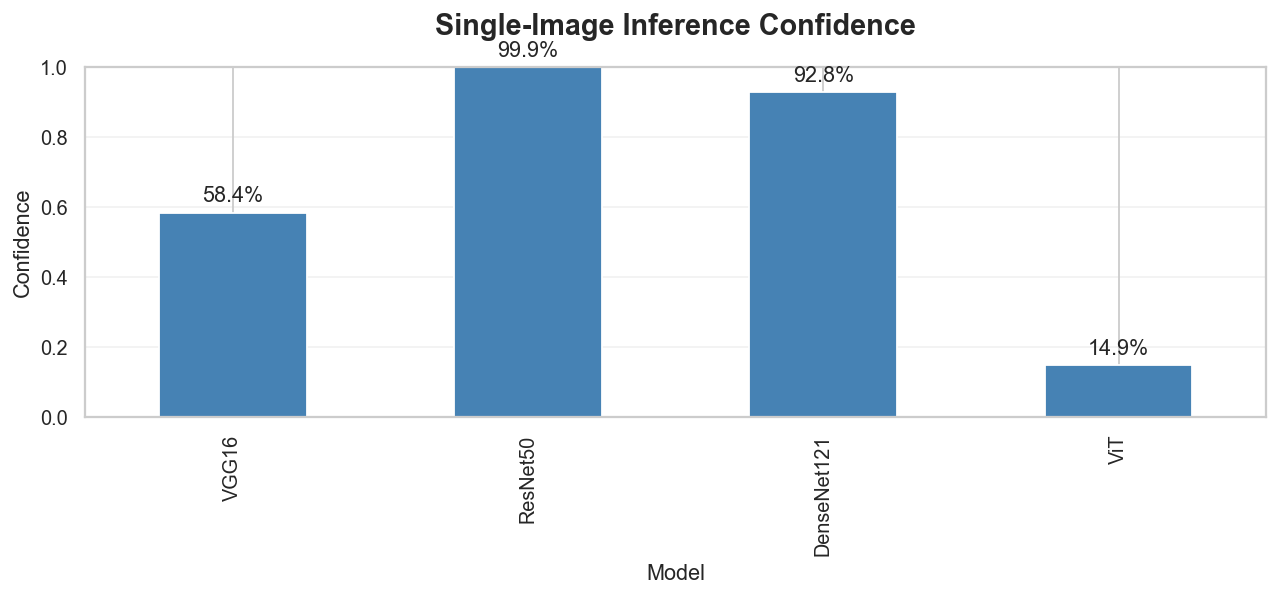

In [11]:
metric_cols = [
    'test_accuracy',
    'weighted_precision',
    'weighted_recall',
    'weighted_f1',
    'macro_precision',
    'macro_recall',
    'macro_f1',
]

metric_view = comparison_df[metric_cols].copy()
metric_view.columns = [
    'Accuracy',
    'Weighted Precision',
    'Weighted Recall',
    'Weighted F1',
    'Macro Precision',
    'Macro Recall',
    'Macro F1',
]

display(metric_view)

fig, ax = plt.subplots(figsize=(14, 6))
metric_view[['Accuracy', 'Weighted F1', 'Macro F1']].plot(kind='bar', ax=ax, width=0.8)
ax.set_ylim(0, 1.05)
ax.set_title('Test-Set Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('comparison_test_metrics.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
comparison_df['inference_confidence'].plot(kind='bar', color='steelblue', ax=ax)
ax.set_ylim(0, 1.0)
ax.set_title('Single-Image Inference Confidence', fontsize=16, fontweight='bold', pad=18)
ax.set_xlabel('Model')
ax.set_ylabel('Confidence')
ax.grid(axis='y', alpha=0.25)

for index, value in enumerate(comparison_df['inference_confidence']):
    ax.text(index, value + 0.02, f'{value * 100:.1f}%', ha='center', va='bottom')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('comparison_inference_confidence.png', bbox_inches='tight')
plt.show()

## How To Read The Comparison

- The curves highlight stability and generalization: the best model is not the one with the highest training accuracy, but the one that keeps validation loss and validation accuracy balanced.
- The test metrics table lets you compare accuracy, precision, recall, and F1 across weighted and macro averages.
- The inference confidence chart is useful for spotting models that are correct but uncertain, such as the VGG example that originally sat below the CNN baselines.

If you rerun the training notebooks after the ViT fixes, this notebook will update automatically because it reads the saved outputs and history file directly.